# Ocean motion: fields, paths and waves

Inspired by **Sunwake Sailing Game**, Thomas Ricouard:
[catalog](https://github.com/magiccreator-ai/awesome-gpt-6-astra#sunwake-sailing-game) ·
[creator post](https://x.com/Dimillian/status/2096863961203220741), and **Navier–Stokes Visual Essay**, ashe:
[catalog](https://github.com/magiccreator-ai/awesome-gpt-6-astra#navierstokes-visual-essay) ·
[creator essay](https://ashe.ai/explainers/navier-stokes/).
[Our animated ocean](https://jltobias.github.io/JupyterLite-Astra-demos/demos/?scene=ocean)

**Learn:** distinguish velocity arrows, particle paths and a changing wave surface.
**Predict:** does a particle move in the direction of the arrow at its current location?
This prescribed vortex and sinusoidal wave field uses dimensionless units. It is not a
Navier–Stokes solver or an ocean forecast; surface height and horizontal current are separate models.


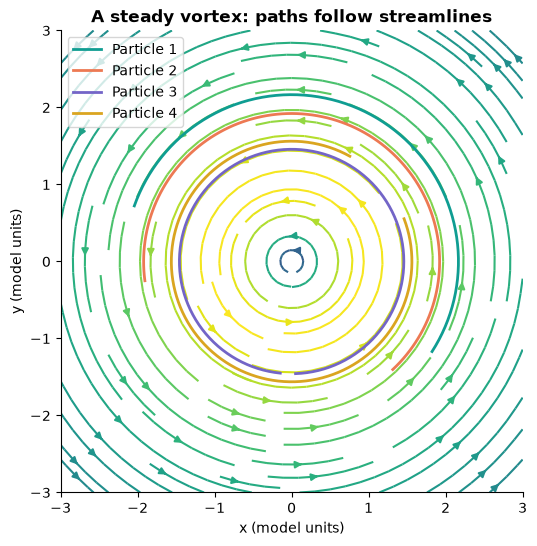

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astra_utils import style, animate_tracks
style()
def velocity(p):
    x,y = p[...,0],p[...,1]
    r2 = x*x+y*y
    return np.stack((-y/(1+r2),x/(1+r2)),axis=-1)

axis = np.linspace(-3,3,23)
X,Y = np.meshgrid(axis,axis)
V = velocity(np.stack((X,Y),axis=-1))
rng = np.random.default_rng(10)
p = rng.uniform(-2,2,(16,2))
dt = .08
tracks = [p.copy()]
for _ in range(240):
    # Midpoint integration follows the velocity at a predicted half step.
    p = p + dt*velocity(p+dt/2*velocity(p))
    tracks.append(p.copy())
tracks = np.array(tracks)
fig, ax = plt.subplots(figsize=(7,6))
ax.streamplot(X,Y,V[...,0],V[...,1],color=np.linalg.norm(V,axis=-1),cmap='viridis',density=1)
for i in range(4):
    ax.plot(*tracks[:,i,:].T,lw=2,label=f'Particle {i+1}')
ax.set(xlim=(-3,3),ylim=(-3,3),aspect='equal',xlabel='x (model units)',ylabel='y (model units)',title='A steady vortex: paths follow streamlines')
ax.legend()
plt.show()


In [2]:
animate_tracks(tracks,(-3,3,-3,3),'Particles in a prescribed vortex',dt=dt,units='model time')


Interactive animation: run this cell in JupyterLite to play or scrub.

**Observe:** particles at different radii have different angular speeds. In a steady field the
streamlines and pathlines coincide; in a changing field they need not. Here speed falls with radius
beyond the unit circle. The animation contains coordinates, not a sequence of pre-rendered movie frames.


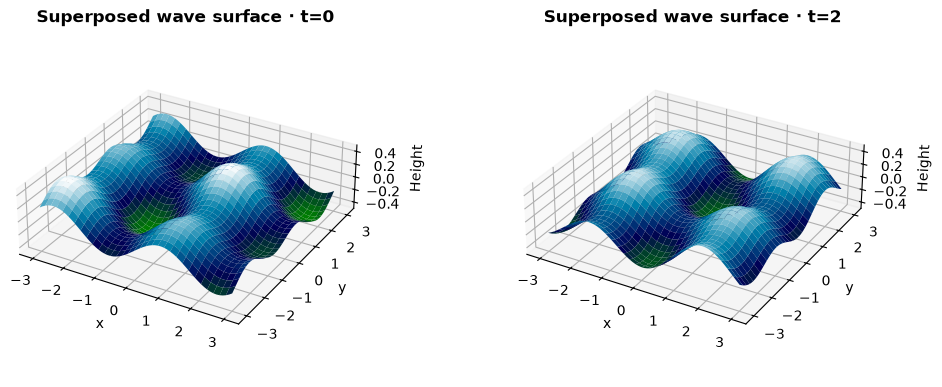

Largest radius drift from the integrator: 0.00011188447197507667


In [3]:
def wave(x,y,t):
    return .25*np.sin(1.8*x-.9*t) + .12*np.sin(2.2*y-1.3*t) + .08*np.sin(x+y-1.8*t)
Xw,Yw = np.meshgrid(np.linspace(-3,3,65),np.linspace(-3,3,65))
fig = plt.figure(figsize=(12,4.5))
for i,t in enumerate([0,2]):
    ax = fig.add_subplot(1,2,i+1,projection='3d')
    ax.plot_surface(Xw,Yw,wave(Xw,Yw,t),cmap='ocean',vmin=-.45,vmax=.45,linewidth=0)
    ax.set(title=f'Superposed wave surface · t={t}',xlabel='x',ylabel='y',zlabel='Height',zlim=(-.5,.5))
    ax.set_box_aspect((1,1,.3))
plt.show()
radii = np.linalg.norm(tracks,axis=2)
print('Largest radius drift from the integrator:',float(np.max(abs(radii-radii[0]))))
assert np.max(abs(radii-radii[0])) < .01


**Experiment:** double `dt` while halving the number of steps. Compare radius drift over the same
total time. Increasing step size makes numerical error visible even though the field did not change.
In the World Lab, change wave amplitude: height grows while the chosen frequencies stay fixed.

**Explain:** a moving crest is a pattern, not necessarily the trajectory of a water parcel.
More realism needs coupled fluid equations, boundary conditions and validation against observations.
